In this notebook, we are looking at the paper:
*   Burns et al.: Deep Learning Foundation Models from Classical Molecular Descriptors. 2026, [arXiv:2506.15792](https://arxiv.org/pdf/2506.15792), see also the accompanying: [Github repo](https://github.com/JacksonBurns/CheMeleon)

The authors describe pretraining GNNs (in the domain of chemistry/small molecules) on [Mordred descriptor](https://link.springer.com/article/10.1186/s13321-018-0258-y) and report good downstream results using this approach.

Here, we are trying to replicate the results and will train a GNN in *Chemelon*-style from scratch. We will use a different base model, and also instead of pretraining on a million molecules from PubChem, we will only pretrain on 200k molecules taken from the [ZINC database](https://zinc.docking.org/tranches/home/
)


In [1]:
# Mordred is commented out because Mordred descriptors have been precalculated
# and saved to Google Drive during a previous execution

!pip install rdkit
# !pip install mordred
!pip install pytorch_lightning
!pip install torch_geometric
!pip install polaris-lib

from google.colab import drive
import pandas as pd
drive.mount("/content/drive")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.0/37.0 MB 36.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 20.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 66.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 38.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.0/115.0 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.2/139.2 kB 17.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 495.4/495.4 kB 34.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 135.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 39.9/39.9 MB 27.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.3/211.3 kB 24.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 373.0/373.0 kB 37.6 MB/s eta 0:00:00


The next cell is commented out because it has already been executed previously.

In this cell, we download SMILES strings of the "in-stock" tranche in ZINC. The "ZINC-downloader-2D-txt.uri" file can be obtained [here](https://zinc.docking.org/tranches/home/). In total, there are almost 11 million molecules in this tranche.

In [2]:
# import requests
# import io

# !cp -r drive/MyDrive/ZINC-downloader-2D-txt.uri /content/ZINC-downloader-2D-txt.uri

# with open("/content/ZINC-downloader-2D-txt.uri", "r") as f:
#     urls = [x.strip() for x in f.readlines()]

# smiles = []

# headers = {"User-Agent": "Mozilla/5.0"}
# for url in urls:
#     response = requests.get(url, headers=headers)
#     smiles.extend(
#         pd.read_csv(io.BytesIO(response.content), sep="\t")["smiles"].tolist()
#         )

# df = pd.DataFrame(smiles, columns=["smiles"])
# df.to_csv("./drive/MyDrive/zinc_in_stock.csv", index=False)

Let's do the imports and define some hyperparameters.

In [3]:
from abc import ABC
from copy import deepcopy
import gc
import logging
import math
import numbers
from pathlib import Path
import warnings
warnings.filterwarnings("ignore", message=".*`isinstance\\(treespec, LeafSpec\\)` is deprecated.*")
warnings.filterwarnings("ignore", message="The number of training batches")
warnings.filterwarnings("ignore", message=".*Found \\d+ module\\(s\\) in eval mode at the start of training.*", category=UserWarning)

import numpy as np
from rdkit import Chem, RDLogger
from rdkit.Chem import Draw
from rdkit.Chem.MolStandardize import rdMolStandardize
# from mordred import Calculator, descriptors
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import polaris as po
from scipy.sparse import coo_matrix
from scipy.special import expit, softmax
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Dataset, Data
from torch_geometric.nn.conv import GCNConv
import torch_geometric.nn as pyg_nn
from torch_geometric.nn.aggr import (
    MultiAggregation, MeanAggregation, StdAggregation, SoftmaxAggregation)
from torch_geometric.loader import DataLoader as pyg_DataLoader

import torch_geometric.transforms as T
import pytorch_lightning as pl
from pytorch_lightning.callbacks import (
    ModelCheckpoint, EarlyStopping, LearningRateMonitor)
from pytorch_lightning.loggers import CSVLogger
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts

plt.rcParams["figure.dpi"] = 300
plt.rcParams["axes.labelsize"] = 6
plt.rcParams["axes.titlesize"] = 7
plt.rcParams["xtick.labelsize"] = 4
plt.rcParams["ytick.labelsize"] = 4
plt.rcParams["lines.linewidth"] = 1
plt.rcParams["ytick.major.size"] = 2
plt.rcParams["ytick.minor.size"] = 1
plt.rcParams["xtick.major.size"] = 2
plt.rcParams["xtick.minor.size"] = 1
plt.rcParams["legend.fontsize"] = "xx-small"
logging.getLogger("polaris").setLevel(logging.ERROR)
logging.getLogger("pytorch_lightning").setLevel(logging.ERROR)
logger = RDLogger.logger()
logger.setLevel(RDLogger.CRITICAL)
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

seed = 42
rng = np.random.default_rng(seed)

allowed_elements = ["reserved", "H", "C", "O", "N", "S", "P", "F", "Cl", "Br", "I"] # reserved for virtual nodes

cfg_all = {
    "processor": {
        "atom_types": allowed_elements,
        "virtual_node": True,
        "use_edge_attr": True
        }
    }

cfg_chemeleon = {
    "gnn_encoder": {
        "depth": 10,
        "n_graph_embeddings": 1024,
        "n_atom_embeddings_in": len(allowed_elements),
        "n_atom_embeddings_out": int(len(allowed_elements)**(3/5)),
        "residual": True,
        "norm": True,
        "mlp": True
        },
    "train": {
        "mask_ratio": 0.15,
        "batch_size": 4096,
        "epochs": 75,
        "epoch_unfreeze_bb": 0,
        "patience_es": 26,
        "opt": {"lr_init": 2e-4},
        "scheduler": {
            "T_0": 25,
            "T_mult": 1,
            "eta_min": 1e-7
            },
        }
    }
cfg_chemeleon["gnn"] = deepcopy(cfg_chemeleon["gnn_encoder"])
cfg_chemeleon["gnn"]["p_dropout"] = 0.2
cfg_chemeleon["gnn"]["n_targets"] = 1067 # see downstream preprocessing of Mordred features

cuda


We will define some preprocessing steps. We want to remove salts, mixtures, avoid duplicated molecules due to stereochemistry (that is ignored in our notebook anyhow), ensure consistent ionic and tautomeric states etc...

In [4]:
def is_organic(mol):
    for atom in mol.GetAtoms():
        if atom.GetSymbol() == "C":
            has_cc_bond = any([True if x == "C" else False for x in atom.GetNeighbors()])
            has_ch_bond = atom.GetTotalNumHs() > 0
            if has_cc_bond or has_ch_bond:
                return True
    return False


def filter_multifragments(mols, threshold=6):
    """
    Filter out co-crystalls, mixtures
    Not relying on rdMolStandardize.LargestFragmentChooser because here we
    additionally check if the largest
    """
    mols_filtered = []
    for mol in mols:
        frags = Chem.GetMolFrags(mol, asMols=True)
        large_organic_frags = [
            x for x in frags
            if is_organic(x) and x.GetNumHeavyAtoms() >= threshold
            ]
        if len(large_organic_frags) == 1:
            mols_filtered.append(large_organic_frags[0])
    return mols_filtered


def filter_elements(mols, allowed_elements):
    mols_filtered = []
    for mol in mols:
        cond = all([True if atom.GetSymbol() in allowed_elements else False
                    for atom in mol.GetAtoms()])
        if cond:
            mols_filtered.append(mol)
    return mols_filtered


def preprocess_mols2mols(mols, allowed_elements):
    # https://github.com/rdkit/rdkit/blob/master/Docs/Notebooks/MolStandardize.ipynb
    mols_clean = deepcopy(mols)
    mols_clean = [x for x in mols_clean if x is not None]
    mols_clean = [rdMolStandardize.Cleanup(x) for x in mols_clean]

    _ = [Chem.RemoveHs(x, updateExplicitCount=True) for x in mols_clean]
    _ = [Chem.RemoveStereochemistry(x) for x in mols_clean]
    mols_clean = filter_multifragments(mols_clean)
    mols_clean = filter_elements(mols_clean, allowed_elements)

    md = rdMolStandardize.MetalDisconnector()
    mols_clean = [md.Disconnect(x) for x in mols_clean]

    enumerator = rdMolStandardize.TautomerEnumerator()
    enumerator.SetMaxTautomers(100)
    mols_clean = [enumerator.Canonicalize(x) for x in mols_clean]

    uncharger = rdMolStandardize.Uncharger()
    mols_clean = [uncharger.uncharge(x) for x in mols_clean]
    return [x for x in mols_clean if x is not None]

def preprocess_smiles2smiles(smiles, allowed_elements, batch_size):
    smiles_clean = []
    for group in range_groups(0, len(smiles), batch_size):
        # print("IDX", max(group))
        mols = [Chem.MolFromSmiles(smiles[idx]) for idx in group]
        mols_clean = preprocess_mols2mols(mols, allowed_elements)

        smiles_clean.extend([Chem.MolToSmiles(x, canonical=True) for x in mols_clean])

    if len(smiles) != len(smiles_clean):
        warnings.warn("Some SMILES had to be removed...")
    return smiles_clean


def range_groups(start, end, step):
    members = list(range(start, end))
    groups = (members[i:i+step] for i in range(0, len(members), step))
    return groups

Now we will take a subsample of roughly 200k molecules from ZINC "in-stock" tranche, and preprocess it with the above defined function.

This cell is commented out because it has been executed previously and output was save to Google Drive.

In [5]:
# smiles = pd.read_csv("./drive/MyDrive/zinc_in_stock.csv")["smiles"].tolist()
# idx_sample = rng.integers(0, len(smiles), size=int(2e5)).tolist()
# smiles_sample = [smiles[idx] for idx in idx_sample]

# smiles_clean = preprocess_smiles2smiles(smiles_samples, allowed_elements, 2**14)

# smiles_clean = []
# for group in range_groups(0, len(smiles_sample), 2**14):
#     print("IDX", max(group))
#     mols = [Chem.MolFromSmiles(smiles_sample[idx]) for idx in group]
#     mols_clean = preprocess(mols, allowed_elements)

#     smiles_clean.extend([Chem.MolToSmiles(x, canonical=True) for x in mols_clean])


# df = pd.DataFrame(list(set(smiles_clean)), columns=["smiles"])
# df.to_csv("./drive/MyDrive/zinc_in_stock_clean_subsample1.csv", index=False)

Now, we will precalculate Mordred descriptor.

This cell is commented out because it has been executed previously and output was save to Google Drive.

In [6]:
# smiles_clean = pd.read_csv("./drive/MyDrive/zinc_in_stock_clean_subsample1.csv")["smiles"].tolist()
# print(f"After cleaning, there are {len(smiles_clean)} compounds remaining")

# calc = Calculator(descriptors, ignore_3D=True)
# mordred_keys = list(
#     calc(Chem.MolFromSmiles(smiles_clean[0])).asdict().keys()
#     )
# mordred_feats = np.zeros((len(smiles_clean), len(mordred_keys)), dtype=np.float32)
# # mordred_feats = np.load("./drive/MyDrive/y.npy")

# idx_to_delete = []
# for idx in range(len(smiles_clean)):
#     mol_clean = Chem.MolFromSmiles(smiles_clean[idx])
#     if mol_clean is None:
#         idx_to_delete.append(idx)
#     else:
#         mordred_feats_cur = calc(mol_clean).asdict()
#         mordred_feats_cur = np.array([
#             v if isinstance(v, numbers.Number) else np.nan
#             for v in mordred_feats_cur.values()
#             ], dtype=np.float32)
#         mordred_feats[idx] = mordred_feats_cur

#     if idx % 10000 == 0 or idx == len(smiles_clean):
#         print("Saved on iteration", idx, idx_to_delete)
#         np.save(file="./drive/MyDrive/y.npy", arr=mordred_feats)


# print(f"Deleted indices: {idx_to_delete}")
# smiles_clean = [x for idx, x in enumerate(smiles_clean) if idx not in idx_to_delete]
# mordred_feats = np.delete(mordred_feats, idx_to_delete, 0)
# print(len(smiles_clean), mordred_feats.shape)

# df = pd.DataFrame(smiles_clean, columns=["smiles"])
# df.to_csv("./drive/MyDrive/zinc_in_stock_clean_subsample2.csv", index=False)
# np.save(file="./drive/MyDrive/y.npy", arr=mordred_feats)
# print("Succesfully saved", len(smiles_clean), mordred_feats.shape)

Somehow, some Mordred descriptor yield nan values (I have not investigated the root cause). We remove/deal with these instance in the following cell. Next to that, we deal with outliers and scale. Burns et al. rely on Windsorizing Mordred descriptors. We extend this by using a robust approach to Windsorization relying on median and median absolute deviation instead of mean and standard deviation. Subsequently, we standard scale.

This cell is commented out because it has been executed previously and output was save to Google Drive.

In [7]:
# smiles_clean = pd.read_csv("./drive/MyDrive/zinc_in_stock_clean_subsample2.csv")["smiles"].tolist()
# y = np.load("./drive/MyDrive/y.npy")

# col_nan_ratio = np.isnan(y).mean(axis=0)
# mask_cols_to_keep0 = col_nan_ratio < 0.01
# print(f"We will drop {y.shape[1] - mask_cols_to_keep0.sum()} columns because they contain > 1% nan values")
# y = y[:, mask_cols_to_keep0]

# mask_rows_to_keep = np.all(~np.isnan(y), axis=1)
# print(f"From the remaining columns that still contain a low amount of rows with nan values, we will instead drop these rows. In total {y.shape[0] - mask_rows_to_keep.sum()} rows are dropped.")
# y = y[mask_rows_to_keep, :]
# smiles_clean = [x for x, keep in zip(smiles_clean, mask_rows_to_keep) if keep]

# medians = np.median(y, axis=0)
# mads = np.median(np.abs(y - medians), axis=0)
# # Windsorization
# y = np.clip(
#     a=y,
#     a_min=medians - 5 * mads,
#     a_max=medians + 5 * mads
#     )
# means = np.mean(y, axis=0)
# stds = np.std(y, axis=0)
# mask_cols_to_keep1 = (stds != 0)
# print(f"We will drop {y.shape[1] - mask_cols_to_keep1.sum()} columns because they contain zero variance")
# y_scaled = (y[:, mask_cols_to_keep1] - means[mask_cols_to_keep1]) / stds[mask_cols_to_keep1]
# np.save(file="./drive/MyDrive/y_scaled.npy", arr=y_scaled)
# df = pd.DataFrame(smiles_clean, columns=["smiles"])
# df.to_csv("./drive/MyDrive/zinc_in_stock_clean_subsample3.csv", index=False)

Reloading the pretraining data and performing train/val split.

In [8]:
smiles = pd.read_csv(
    "./drive/MyDrive/zinc_in_stock_clean_subsample3.csv")["smiles"].tolist()
y = np.load("./drive/MyDrive/y_scaled.npy")

idxs_train = rng.choice(len(smiles), int(0.7 * len(smiles)), replace=False)
mask_train = np.zeros(len(smiles), dtype=bool)
mask_train[idxs_train] = True

smiles_train = [x for idx, x in enumerate(smiles) if idx in idxs_train]
smiles_val = [x for idx, x in enumerate(smiles) if idx not in idxs_train]
y_train = y[mask_train, :]
y_val = y[~mask_train, :]

Functionality to convert molecules into graphs:

In [9]:
class MoleculeProcessor:
    def __init__(self, atom_types, virtual_node, use_edge_attr):
        self.dic_atoms = {symbol: idx for idx, symbol in enumerate(atom_types)}
        self.dic_bonds = {
            "SINGLE": 1,  "AROMATIC": 1.5, "DOUBLE": 2, "TRIPLE": 3}
        self.use_edge_attr = use_edge_attr

        transforms = []
        if virtual_node:
            transforms.append(T.VirtualNode())

        self.transforms = T.Compose(transforms)

    def smile_to_mol(self, smile):
        return Chem.MolFromSmiles(smile)

    def smile_to_data(self, smile):
        """
        Parameters
        ----------
        smile: str

        Returns
        -------
        _: torch_geometric.data.data.Data
        """
        mol = self.smile_to_mol(smile)
        edge_idx = self.get_edge_idx(mol)
        x = self.get_x(mol)

        edge_attr = None
        if self.use_edge_attr:
            edge_attr = self.get_edge_attr(mol, edge_idx)

        data = Data(x=x, edge_index=edge_idx, edge_attr=edge_attr)
        return self.transforms(data)

    def get_x(self, mol):
        """
        Parameters
        ----------
        mol: rdkit.Chem.rdchem.Mol

        Returns
        -------
        _: torch.tensor of shape (n_atoms, 1)
        """
        x = torch.tensor(
            [self.dic_atoms[atom.GetSymbol()] for atom in mol.GetAtoms()],
            dtype=torch.int32)[:, None]
        return x

    def get_edge_idx(self, mol):
        """
        Parameters
        ----------
        mol: rdkit.Chem.rdchem.Mol

        Returns
        -------
        edge_idx: torch.tensor of shape (2, n_edges)
        """
        adj = coo_matrix(Chem.GetAdjacencyMatrix(mol))
        edge_idx = torch.stack([
            torch.tensor(adj.row, dtype=torch.long),
            torch.tensor(adj.col, dtype=torch.long)], dim=0)
        return edge_idx

    def get_edge_attr(self, mol, edge_idx):
        """
        Parameters
        ----------
        mol: rdkit.Chem.rdchem.Mol
        edge_idx: torch.tensor of shape (2, n_edges)

        Returns
        -------
        edge_attr: torch.tensor of shape (n_edges,)
        """
        edge_attr = torch.zeros((edge_idx.shape[1],), dtype=torch.float32)

        for idx in range(edge_idx.shape[1]):
            bond_type = str(
                mol.GetBondBetweenAtoms(
                    int(edge_idx[0, idx]), int(edge_idx[1, idx])
                    ).GetBondType()
                )
            edge_attr[idx] = self.dic_bonds[bond_type] / 3
        return edge_attr

Defining Pytorch Geometric datasets and loaders:

In [10]:
class MoleculeDataset(Dataset):
    def __init__(self, smiles, processor, y=None):
        super().__init__()
        self.smiles = smiles
        self.processor = processor
        if y is None:
            self.y = None
        else:
            self.y = torch.tensor(y, dtype=torch.float32)

    def len(self):
        return len(self.smiles)

    def get(self, idx):
        smile = self.smiles[idx]

        data = self.processor.smile_to_data(smile)
        if self.y is not None:
            return data, self.y[idx, :]
        return data


def get_loaders(smiles, y, cfg, cfg_all, device, shuffle):
    processor = MoleculeProcessor(**cfg_all["processor"])

    ds = MoleculeDataset(
        smiles=smiles, processor=processor, y=y)
    loader = pyg_DataLoader(
        ds,
        batch_size=cfg["train"]["batch_size"],
        shuffle=shuffle,
        num_workers=2,
        pin_memory=True if device == "cuda" else False
        )
    return loader

Our models (and custom MaskedMSE loss):

In [11]:
class BaseModule(ABC):
    def _initialize(self, module):
        for m in module.modules():
            if isinstance(m, (nn.Linear, pyg_nn.dense.linear.Linear, nn.Conv2d)):
                torch.nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    torch.nn.init.zeros_(m.bias)
            elif isinstance(m, (nn.BatchNorm1d, nn.BatchNorm2d)):
                torch.nn.init.constant_(m.weight, 1)
                torch.nn.init.constant_(m.bias, 0)

    def _freeze(self):
        for param in self.parameters():
            param.requires_grad = False

        for m in self.modules():
            if isinstance(m, (nn.BatchNorm1d, nn.BatchNorm2d)):
                m.eval()
                m.track_running_stats = False
        print("Freezing")

    def _unfreeze(self):
        for param in self.parameters():
            param.requires_grad = True

        for m in self.modules():
            if isinstance(m, (nn.BatchNorm1d, nn.BatchNorm2d)):
                m.train()
                m.track_running_stats = True
        print("Unfreezing")

    @classmethod
    def load_from_pt(cls, fp, init_kwargs):
        state_dict = torch.load(fp, map_location=torch.device("cpu"))
        model = cls(**init_kwargs)
        model.load_state_dict(state_dict)
        model.eval()
        print("Loaded")
        return model

    def save_to_pt(self, fp):
        Path(fp).parent.mkdir(parents=True, exist_ok=True)
        torch.save(self.state_dict(), fp)
        print("Saved")


class MLP(nn.Module, BaseModule):
    def __init__(self, neurons, dropout=0.0, activation=nn.ReLU):
        super().__init__()
        modules = []
        for i in range(len(neurons) - 1):
            modules.append(nn.Linear(neurons[i], neurons[i+1]))
            if i != len(neurons) - 2:
                modules.append(activation())
                modules.append(nn.Dropout(dropout))
        self.mlp = nn.Sequential(*modules)
        self.apply(self._initialize)

    def forward(self, x):
        return self.mlp(x)


class GCNLayer(nn.Module, BaseModule):
    def __init__(self, channels_in, channels_out, residual=True, norm=True,
                 mlp=True, activation=nn.ReLU):
        super().__init__()
        self.gcn = GCNConv(channels_in, channels_out, improved=True)

        self.act = activation()
        self.residual = residual
        self.norm = norm
        self.mlp = mlp
        if self.norm:
            self.norm0 = nn.BatchNorm1d(channels_out)
            if self.mlp:
                self.norm1 = nn.BatchNorm1d(channels_out)
                self.norm2 = nn.BatchNorm1d(channels_out)

        if self.mlp:
            self.mlp0 = MLP([channels_out, channels_out*2, channels_out])
        self.apply(self._initialize)

    def forward(self, x, edge_index, edge_weight):
        x_in = x

        x = self.gcn(x, edge_index, edge_weight)
        if self.norm:
            x = self.norm0(x)
        x = self.act(x)
        if self.residual:
            x = x + x_in
        if self.mlp:
            if self.norm:
                x = self.norm1(x)
            x = self.mlp0(x)
            if self.norm:
                x = self.norm2(x)
        return x


class GNNEncoder(nn.Module, BaseModule):
    def __init__(self, depth, n_graph_embeddings, n_atom_embeddings_in,
                 n_atom_embeddings_out, residual=True, norm=True, mlp=True):
        super().__init__()
        self.embed = nn.Embedding(n_atom_embeddings_in, n_atom_embeddings_out)
        self.gnn = nn.ModuleList(
            [GCNLayer(
                channels_in=n_atom_embeddings_out,
                channels_out=n_graph_embeddings,
                residual=False,
                norm=norm,
                mlp=mlp
                )] +
            [GCNLayer(
                channels_in=n_graph_embeddings,
                channels_out=n_graph_embeddings,
                residual=residual,
                norm=norm,

                mlp=mlp
                )
             for _ in range(depth - 1)]
            )
        self.agg = MultiAggregation([
            MeanAggregation(),
            StdAggregation(),
            SoftmaxAggregation(t=0.1, learn=True)
            ])

    def forward(self, batch):
        x = self.embed(batch.x[:, 0])

        for gnn_layer in self.gnn:
            x = gnn_layer(x, batch.edge_index, batch.edge_attr)

        x = self.agg(x, batch.batch)
        return x


class GNN(nn.Module, BaseModule):
    def __init__(self, depth, n_graph_embeddings, n_atom_embeddings_in,
                 n_atom_embeddings_out, p_dropout, n_targets, residual=True,
                 norm=True, mlp=True):
        super().__init__()
        self.encoder = GNNEncoder(
            depth=depth,
            n_graph_embeddings=n_graph_embeddings,
            n_atom_embeddings_in=n_atom_embeddings_in,
            n_atom_embeddings_out=n_atom_embeddings_out,
            residual=residual,
            norm=norm,
            mlp=mlp
            )
        self.p_dropout = p_dropout
        mlp_neurons = [n_graph_embeddings * 3, n_graph_embeddings * 6,
                       n_graph_embeddings * 3, n_targets]
        self.mlp = MLP(mlp_neurons)

    def forward(self, batch):
        x = self.encoder(batch)
        x = F.dropout(x, self.p_dropout, training=self.training)
        x = self.mlp(x)
        return x


class MaskedMSELoss(nn.Module):
    def __init__(self, mask_ratio):
        super().__init__()
        self.mask_ratio = mask_ratio

    def forward(self, y_pred, y_true):
        mask = (torch.rand_like(y_true) < self.mask_ratio)
        squared_errors = (y_pred - y_true)**2
        return squared_errors[mask].mean()

Our PytorchLightning module for training:

In [12]:
class GNNModule(pl.LightningModule):
    def __init__(self, gnn, cfg_train, criterion_train, criterion_val):
        super().__init__()
        self.automatic_optimization = False
        self.model = gnn
        self.criterion_train = criterion_train
        self.criterion_val = criterion_val
        self.cfg_train = cfg_train

    def training_step(self, batch, batch_idx):
        data, y_true = batch
        opt = self.optimizers()

        y_pred = self.model(data)

        loss = self.criterion_train(y_pred, y_true.view(data.num_graphs, -1))
        self.log("train_loss", loss, on_step=False, on_epoch=True,
                 prog_bar=True, batch_size=self.cfg_train.get("batch_size"))

        self.manual_backward(loss)
        opt.step()
        opt.zero_grad()

    def on_train_epoch_start(self):
        if self.current_epoch == self.cfg_train["epoch_unfreeze_bb"]:
            self.model.encoder._unfreeze()

    def on_train_epoch_end(self):
        scheduler = self.lr_schedulers()
        scheduler.step()

    def validation_step(self, batch, batch_idx):
        data, y_true = batch
        y_pred = self.model(data)

        loss = self.criterion_val(y_pred, y_true.view(data.num_graphs, -1))
        self.log("val_loss", loss, on_step=False, on_epoch=True,
                 prog_bar=True, batch_size=self.cfg_train.get("batch_size"))
        return loss

    def configure_optimizers(self):
        opt = torch.optim.Adam([
            {"params": self.model.parameters(),
             "lr": self.cfg_train.get("opt").get("lr_init")
             },
            ])

        scheduler = CosineAnnealingWarmRestarts(
            optimizer=opt,
            T_0=self.cfg_train.get("scheduler").get("T_0"),
            T_mult=self.cfg_train.get("scheduler").get("T_mult"),
            eta_min=self.cfg_train.get("scheduler").get("eta_min")
            )
        return [opt], [scheduler]

A train function that can be reused later:

In [13]:
def train(name, cfg, loader_train, loader_val, criterion_train, criterion_val, device, fp_encoder=None):
    gnn = GNN(**cfg["gnn"])
    if fp_encoder is not None:
        gnn.encoder = GNNEncoder.load_from_pt(
            fp=fp_encoder, init_kwargs=cfg["gnn_encoder"])
        gnn.encoder._freeze()

    module = GNNModule(
        gnn=gnn,
        cfg_train=cfg["train"],
        criterion_train=criterion_train,
        criterion_val=criterion_val
        )

    cb_a = ModelCheckpoint(monitor="val_loss", mode="min")
    cb_b = EarlyStopping(
        monitor="val_loss", mode="min",
        patience=cfg["train"].get("patience_es")
        )
    cb_c = LearningRateMonitor(logging_interval="epoch")
    logger = CSVLogger(
        save_dir="logs/", name=f"_{name}", flush_logs_every_n_steps=1)

    trainer = pl.Trainer(
        max_epochs=cfg["train"]["epochs"],
        check_val_every_n_epoch=1,
        callbacks=[cb_a, cb_b, cb_c],
        logger=logger,
        accelerator=device,
        enable_progress_bar=False, # XX
        enable_model_summary=False
        )

    trainer.fit(
        model=module,
        train_dataloaders=loader_train,
        val_dataloaders=loader_val
        )

    checkpoint_file = trainer.checkpoint_callback.best_model_path
    module_best = GNNModule.load_from_checkpoint(
        checkpoint_file,
        gnn=gnn,
        cfg_train=cfg["train"],
        criterion_train=criterion_train,
        criterion_val=criterion_val
        )
    return trainer, module_best.model


def display_loss(trainer, names_loss, y_lim):
    logs = pd.read_csv(Path(trainer.logger.log_dir + "/metrics.csv"))
    epochs = logs.dropna(subset=[names_loss[0]])["epoch"]
    fig, ax = plt.subplots(figsize=(3, 2))
    labels = []
    colors = ["r", "b"]
    for idx, name_loss in enumerate(names_loss):
        labels.extend(
            ax.plot(
                epochs, logs[name_loss].dropna(),
                color=colors[idx],
                label=name_loss
                )
            )
    ax.set_xlabel("epochs")
    ax.set_ylabel("loss")

    ax.set_ylim(y_lim[0], y_lim[1])
    ax.legend(
        labels, [l.get_label() for l in labels], loc="lower center",
        bbox_to_anchor=(0, 1.05, 1, 0.2), ncol=3
        )
    plt.show()

And finally start to pretrain our model in *CheMeleon*-style. This cell is commented out because it has been executed previously and the model has been saved to the Google Drive:

In [14]:
loader_train_chemeleon = get_loaders(
    smiles=smiles_train, y=y_train, cfg=cfg_chemeleon, cfg_all=cfg_all,
    device=device, shuffle=True)
loader_val_chemeleon = get_loaders(
    smiles=smiles_val, y=y_val, cfg=cfg_chemeleon, cfg_all=cfg_all,
    device=device, shuffle=False)

# trainer_chemeleon, model_chemeleon_best = train(
#     name="chemeleon",
#     cfg=cfg_chemeleon,
#     loader_train=loader_train_chemeleon,
#     loader_val=loader_val_chemeleon,
#     criterion_train=MaskedMSELoss(cfg_chemeleon["train"].get("mask_ratio")),
#     criterion_val=nn.MSELoss(),
#     device=device
#     )

# display_loss(trainer_chemeleon, ["train_loss", "val_loss"], y_lim=[0, 0.7])

# model_chemeleon_best.encoder.save_to_pt(
#     "./drive/MyDrive/gnn_encoder_chemeleon.pt")

Now, we want to benchmark how useful our pretrained model is. Benchmarking will rely on datasets from [Polaris](https://polarishub.io/)

In [15]:
def benchmarking(name, cfg, cfg_all, y_lim, seeds, device):
    results = []
    for seed in seeds:
        torch.manual_seed(seed)

        # Get data ready
        benchmark = po.load_benchmark(name)
        col_smiles = list(benchmark.input_cols)[0]
        cols_target = list(benchmark.target_cols)
        task_type = benchmark.target_types[cols_target[0]]

        benchmark_train, benchmark_test = benchmark.get_train_test_split()
        _smiles_trainval = benchmark_train.as_dataframe()[col_smiles].tolist()
        smiles_trainval = preprocess_smiles2smiles(
            _smiles_trainval, cfg_all["processor"]["atom_types"], batch_size=16)

        # Really annoying behavior of polaris that seems to duplicate columns...
        tmp = benchmark_train.as_dataframe()[cols_target]
        y_trainval = tmp.loc[:, ~tmp.columns.duplicated()].values

        smiles_train, smiles_val, y_train, y_val = train_test_split(
            smiles_trainval, y_trainval, test_size=0.2, random_state=seed)

        _smiles_test = benchmark_test.as_dataframe()[col_smiles].tolist()
        smiles_test = preprocess_smiles2smiles(
            _smiles_test, cfg_all["processor"]["atom_types"], batch_size=16)

        if task_type.name == "CLASSIFICATION" and len(cols_target) == 1:
            cfg["gnn"]["n_targets"] = 1
            _, counts = np.unique(y_train, return_counts=True)
            pos_weight = torch.tensor(counts[0] / counts[1], dtype=torch.float32)

            criterion_train = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
            criterion_val = nn.BCEWithLogitsLoss()
            scaler = None
        elif task_type.name == "REGRESSION":
            cfg["gnn"]["n_targets"] = 1
            criterion_train = nn.MSELoss()
            criterion_val = nn.MSELoss()
            scaler = StandardScaler()
            y_train = scaler.fit_transform(y_train)
            y_val = scaler.transform(y_val)
        else:
            raise NotImplementedError("Not implemented")

        loader_train = get_loaders(
            smiles=smiles_train, y=y_train, cfg=cfg, cfg_all=cfg_all,
            device=device, shuffle=True)
        loader_val = get_loaders(
            smiles=smiles_val, y=y_val, cfg=cfg, cfg_all=cfg_all,
            device=device, shuffle=False)
        loader_test = get_loaders(
            smiles=smiles_test, y=None, cfg=cfg, cfg_all=cfg_all,
            device=device, shuffle=False)

        trainer, model_best = train(
            name=name + f"_{seed}",
            cfg=cfg,
            loader_train=loader_train,
            loader_val=loader_val,
            criterion_train=criterion_train,
            criterion_val=criterion_val,
            device=device,
            fp_encoder="./drive/MyDrive/gnn_encoder_chemeleon.pt"
            )

        # Test
        y_pred = []
        model_best.to(device)
        model_best.eval()
        with torch.no_grad():
            for batch_idx, mol_batch in enumerate(loader_test):
                y_pred_batch = model_best(mol_batch.to(device)).cpu().numpy()
                y_pred.append(y_pred_batch)

        y_pred = np.concatenate(y_pred, axis=0)

        if task_type.name == "CLASSIFICATION" and len(cols_target) == 1:
            y_pred = expit(y_pred)
            result = benchmark.evaluate(y_pred > 0.5, y_pred).results
        elif task_type.name == "REGRESSION":
            y_pred = scaler.inverse_transform(y_pred)
            result = benchmark.evaluate(y_pred.flatten()).results
        else:
            raise NotImplementedError("Not implemented")

        results.append(result.query(f"Metric == '{benchmark.main_metric.label}'")["Score"].values[0])

        # Prevent memory leak
        del trainer, model_best, loader_train, loader_val, loader_test,
        del tmp, _smiles_trainval, _smiles_test, smiles_train, smiles_val, smiles_test, y_trainval, y_train, y_val,
        if device == "cuda":
            torch.cuda.empty_cache()
        gc.collect()

    out = {name: (benchmark.main_metric.label, np.stack(results, axis=0))}
    print(name, (benchmark.main_metric.label, np.stack(results, axis=0)))
    del benchmark, benchmark_train, benchmark_test
    return out

Let's define hyperparameters for benchmarking and what benchmarks are evaluated.

We will only evaluate a subset of the benchmarks performed in the paper by Burns et al., primarily because many of the benchmarks contain molecules that are incompatible with the preprocessing steps defined above (i.e., contain elements that were filtered out for pretraining).

In [16]:
cfg_benchmark = {
    "train": {
        "batch_size": 128,
        "epochs": 80,
        "epoch_unfreeze_bb": 67,
        "patience_es": 80,
        "opt": {"lr_init": 1e-4},
        "scheduler": {
            "T_0": 20,
            "T_mult": 1,
            "eta_min": 1e-7
            },
        }
    }
cfg_benchmark["gnn_encoder"] = cfg_chemeleon["gnn_encoder"]
cfg_benchmark["gnn"] = deepcopy(cfg_benchmark["gnn_encoder"])
cfg_benchmark["gnn"]["p_dropout"] = 0.2

results_chemeleon = {}
benchmark_names = [
    "polaris/pkis2-ret-wt-cls-v2",
    "polaris/adme-fang-perm-1",
    "polaris/adme-fang-hclint-1",
    "polaris/pkis2-egfr-wt-reg-v2",
    "polaris/pkis2-ret-wt-reg-v2",
    "polaris/pkis2-kit-wt-cls-v2"
    ]

for benchmark_name in benchmark_names:
    results = benchmarking(
        name=benchmark_name,
        cfg=cfg_benchmark,
        cfg_all=cfg_all,
        y_lim=[0, 1],
        seeds=[42, 117, 709, 1701, 9001],
        device=device
        )
    results_chemeleon.update(results)

Output()

[15:15:25]  Success: Fetching dataset                                                                 ]8;id=402397;file:///usr/local/lib/python3.12/dist-packages/polaris/utils/context.py\context.py]8;;\:]8;id=333748;file:///usr/local/lib/python3.12/dist-packages/polaris/utils/context.py#53\53]8;;\

            Success: Fetching benchmark                                                               ]8;id=12300;file:///usr/local/lib/python3.12/dist-packages/polaris/utils/context.py\context.py]8;;\:]8;id=82394;file:///usr/local/lib/python3.12/dist-packages/polaris/utils/context.py#53\53]8;;\

Loaded
Freezing
Unfreezing


[15:19:26]  Success: Fetching dataset                                                                 ]8;id=11627;file:///usr/local/lib/python3.12/dist-packages/polaris/utils/context.py\context.py]8;;\:]8;id=851380;file:///usr/local/lib/python3.12/dist-packages/polaris/utils/context.py#53\53]8;;\

...

            Success: Fetching benchmark                                                               ]8;id=564277;file:///usr/local/lib/python3.12/dist-packages/polaris/utils/context.py\context.py]8;;\:]8;id=148931;file:///usr/local/lib/python3.12/dist-packages/polaris/utils/context.py#53\53]8;;\

Loaded
Freezing
Unfreezing


[21:35:19]  Success: Fetching dataset                                                                 ]8;id=100546;file:///usr/local/lib/python3.12/dist-packages/polaris/utils/context.py\context.py]8;;\:]8;id=419544;file:///usr/local/lib/python3.12/dist-packages/polaris/utils/context.py#53\53]8;;\

            Success: Fetching benchmark                                                               ]8;id=466004;file:///usr/local/lib/python3.12/dist-packages/polaris/utils/context.py\context.py]8;;\:]8;id=350421;file:///usr/local/lib/python3.12/dist-packages/polaris/utils/context.py#53\53]8;;\

Loaded
Freezing
Unfreezing
polaris/pkis2-kit-wt-cls-v2 ('pr_auc', array([0.60149342, 0.5264294 , 0.50410407, 0.50874824, 0.55812031]))


We will compare results of our CheMeleon-flavor to those of the original paper and also to the results for MolFormer (as benchmarked by Burns et al.) and visualize the results:

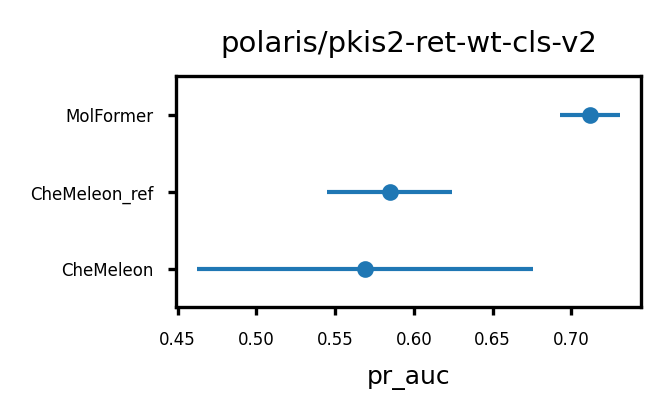

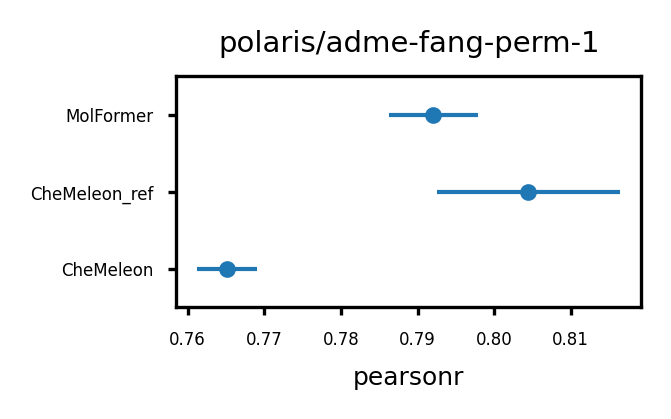

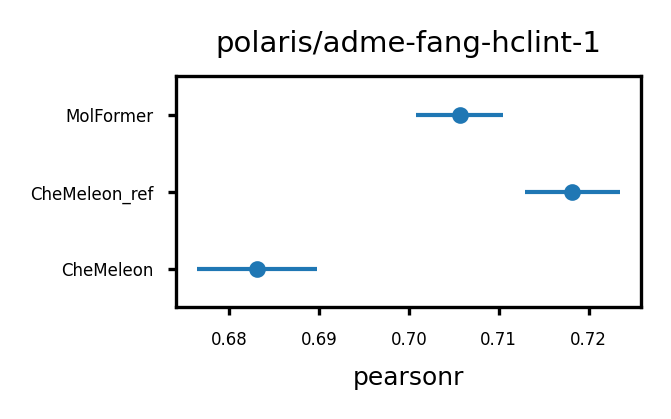

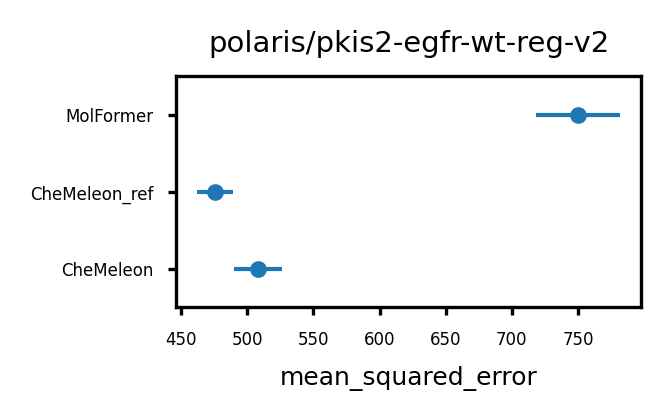

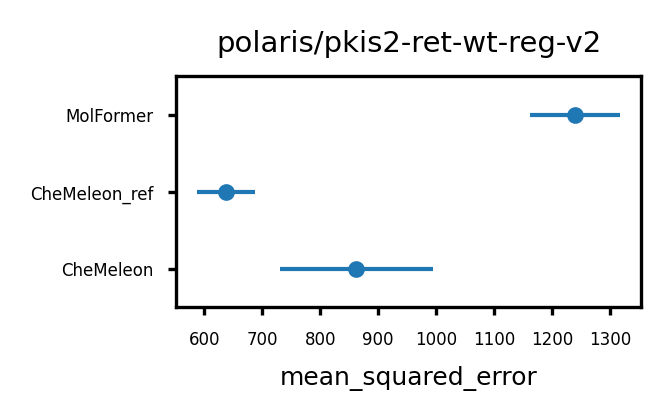

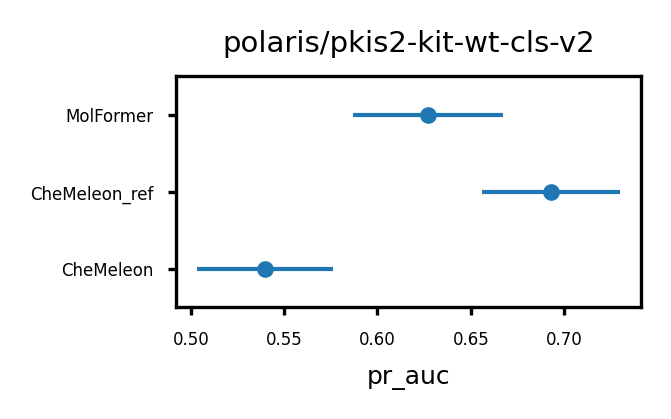

In [17]:
# https://github.com/JacksonBurns/chemeleon/blob/main/analysis/polaris_results/CheMeleon.md
results_chemeleon_ref = {
    "polaris/pkis2-ret-wt-cls-v2": ("pr_auc", np.array([0.531761, 0.608151, 0.640322, 0.548253, 0.594504])),
    "polaris/adme-fang-perm-1": ("pearsonr", np.array([0.792771, 0.813951, 0.796288, 0.823254, 0.796132])),
    "polaris/adme-fang-hclint-1": ("pearsonr", np.array([0.716771, 0.713363, 0.713181, 0.727528, 0.720122])),
    "polaris/pkis2-egfr-wt-reg-v2": ("mean_squared_error", np.array([485.443, 470.642, 452.034, 489.633, 481.225])),
    "polaris/pkis2-ret-wt-reg-v2": ("mean_squared_error", np.array([710.026, 561.61, 641.2, 611.952, 664.25])),
    "polaris/pkis2-kit-wt-cls-v2": ("pr_auc", np.array([0.709325, 0.686911, 0.62661, 0.705488, 0.737108])),
    }

# https://github.com/JacksonBurns/chemeleon/blob/main/analysis/polaris_results/MoLFormer.md
results_molformer_ref = {
    "polaris/pkis2-ret-wt-cls-v2": ("pr_auc", np.array([0.685265, 0.741432, 0.716341, 0.698874, 0.717766])),
    "polaris/adme-fang-perm-1": ("pearsonr", np.array([0.794061, 0.783875, 0.794321, 0.800469, 0.78747])),
    "polaris/adme-fang-hclint-1": ("pearsonr", np.array([0.699032, 0.702593, 0.712397, 0.704613, 0.709592])),
    "polaris/pkis2-egfr-wt-reg-v2": ("mean_squared_error", np.array([759.689, 798.468, 738.814, 753.24, 700.606])),
    "polaris/pkis2-ret-wt-reg-v2": ("mean_squared_error", np.array([1359.02, 1124.43, 1266.19, 1199.57, 1251.06])),
    "polaris/pkis2-kit-wt-cls-v2": ("pr_auc", np.array([0.632308, 0.568735, 0.595807, 0.668221, 0.670391])),
    }


for name in results_chemeleon.keys():
      methods = ["CheMeleon", "CheMeleon_ref", "MolFormer"]
      means = [results_chemeleon.get(name)[1].mean(),
               results_chemeleon_ref.get(name)[1].mean(),
               results_molformer_ref.get(name)[1].mean()]
      stds = [results_chemeleon.get(name)[1].std(),
              results_chemeleon_ref.get(name)[1].std(),
              results_molformer_ref.get(name)[1].std()]

      fig, ax = plt.subplots(figsize=(2, 1))
      ax.errorbar(
          x=means,
          y=range(len(methods)),
          xerr=stds,
          fmt="o",
          ms=3
          )
      ax.set_yticks(range(len(methods)), methods)
      ax.set_xlabel(results_chemeleon.get(name)[0])
      ax.set_title(name)
      ax.set_ylim(-0.5, 2.5)

      plt.show()

Conclusion: Inconclusive. It looks like we are slightly less succesful in our attempt than Burns et al., but additional experimentation and benchmarks would be necessary to make a sound conclusion.